# Chemprop v2 — Experiment 1: Default Parity Encoding

This notebook tests Chemprop's default `SimpleMoleculeMolGraphFeaturizer`, which
encodes the `@/@@` SMILES parity tag via RDKit's `ChiralTag` atom feature (values:
`CHI_UNSPECIFIED`, `CHI_TETRAHEDRAL_CW`, `CHI_TETRAHEDRAL_CCW`). This is
**different** from Morgan fingerprints with `includeChirality=True`, which encode
the **CIP R/S label** (confirmed by Greg Landrum, GitHub Issues #2388 and #4013).

**Scientific questions:** what stereochemical signal does the MPNN extract from
the 2D graph, and does it survive the permutation-invariant mean aggregation?

**Conditions in this notebook:**

| Condition | Type | Datapoints | Description |
|---|---|---|---|
| `exp_1_default_parity_singletask` | Single-task | `all_data_stereo` | Default featurizer, implicit Hs |
| `exp_1_default_parity_multitask` | Multi-task | `all_data_stereo` | Default featurizer, implicit Hs, joint 3-target model |

**Total fits:**
- Singletask: 1 condition × 3 targets × 5 folds = 15
- Multitask: 5 folds = 5
- **Total: 20 fits**

**Hypotheses tested:**
1. `@/@@` should be the easiest target for Chemprop (inverse of the RF result), because Chemprop encodes `@/@@` via ChiralTag while the RF encoded CIP R/S.
2. `@/@@` signal should mostly survive the aggregation.
3. Multitask training may slightly improve per-target performance through shared MPNN representations.

Part of series: `3_RF_morgan_count.ipynb` → `4_chemprop_exp_0.ipynb` → **`4_chemprop_exp_1.ipynb`**

In cheminformatics, the @ and @@ symbols in a SMILES string represent the parity of the stereocenter. Parity is a relative directional tag; it describes the spatial arrangement (@ for counter-clockwise and @@ for clockwise) strictly based on the order the atoms are written in the SMILES string.

## Imports

**On warning filters.** Previous draft used `warnings.filterwarnings('ignore', category=UserWarning)`,
but this can hide useful warnings e.g., if a shuffled training dataloader is accidentally used 
for prediction,  Lightning warns via `PossibleUserWarning`, whose MRO is `(PossibleUserWarning, UserWarning, Warning, ...)`, so
blanket-ignoring `UserWarning` silences it. This notebook now filters only four specific messages, 
each verified as benign:
- dataloader worker counts
- a torch pytree deprecation
- Lightning declining to YAML-dump the metrics parameter
- MPS nondeterminism (see Configuration)

In [ ]:
import gc
import re
import time
import warnings
from pathlib import Path

# use specific filters instead generic `filterwarnings('ignore', category=UserWarning)`.
# last entry is MPS non-determinism (expected, not a bug).
for _msg in (
    '.*does not have many workers.*',
    '.*isinstance\\(treespec, LeafSpec\\).*',
    '.*Skipping .metrics. parameter.*',
    '.*does not have a deterministic implementation.*',
):
    warnings.filterwarnings('ignore', message=_msg)

import numpy as np
import pandas as pd
import torch

from lightning import pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from sklearn.metrics import (
    roc_auc_score,
    matthews_corrcoef,
    accuracy_score,
    f1_score,
    average_precision_score,
)

from chemprop import data, featurizers, models, nn

## Configuration

`MONITOR` / `MONITOR_MODE` are the single source of truth for both `EarlyStopping` and
`ModelCheckpoint`. These two callbacks should track the same metric; otherwise, training would 
stop on one notion of "best" while a different epoch's weights get saved.

`val_loss` (BCE, logged by chemprop from `self.metrics[-1]`) is monitored rather than
`val/roc` because:

* BCE is a proper scoring rule, capturing ranking and calibration; AUROC is invariant to
  any monotone rescaling of the scores and so cannot see calibration at all.
* `ModelCheckpoint` compares with `torch.gt` for `mode='max'` (strict), so a saturated AUROC
  never replaces the saved checkpoint and selection freezes on an early, uncalibrated epoch.
  That matters here: `@/@@` is close to perfectly predictable from the ChiralTag feature, so
  its AUROC saturates early.
* For the multitask model `val/roc` is a single AUROC **pooled across all three targets**
  (`ClassificationMixin.update` flattens the task dimension), so it is dominated by whichever
  target is already solved. `BCELoss` carries per-task weights and reduces to a task-weighted
  mean, so solved tasks fade and unsolved ones dominate.

`MIN_EPOCHS` forces the training loop to continue; it does **not** constrain which epoch is
checkpointed (`ModelCheckpoint` has no awareness of it), so `best_epoch` can be smaller than
`MIN_EPOCHS`.

`MIN_DELTA` is the minimum `val_loss` improvement that resets early-stopping patience. Note
`ModelCheckpoint` ignores it and saves on *any* improvement, so `best_epoch` can also be
*later* than the epoch that last reset patience.

**Decision threshold.** Metrics are reported at both the fixed 0.5 cutoff and a threshold
tuned to maximize MCC on validation (`*_tuned` columns). The plain columns stay directly
comparable to `3_RF_morgan_count.ipynb`, whose `RandomForestClassifier.predict()` is a 0.5
cutoff.

Chemprop's MoleculeDataset uses PyTorch's DataLoader object [https://github.com/chemprop/chemprop/blob/main/chemprop/data/datasets.py#L191](https://github.com/chemprop/chemprop/blob/main/chemprop/data/datasets.py#L191).
`num_workers=0` loads data sequentially in the main process. Setting `num_workers=1` forces Python to spawn a separate background process, serialize the data, 
transfer it across shared memory, and deserialize it back. This is not efficient given the size of the dataset here.

In [ ]:
INPUT_PATH  = 'data/class_all.csv'
FOLDS_PATH  = 'data/cmrt_folds.npz'
NUM_WORKERS = 0      # set >0 if multiprocessing is available

# ── Run identity: keeps checkpoints/logs/labels from colliding across re-runs ──
RUN_TAG   = 'exp1_default_parity'
CKPT_ROOT = Path('checkpoints') / RUN_TAG
LOG_ROOT  = Path('logs') / RUN_TAG
CKPT_ROOT.mkdir(parents=True, exist_ok=True)
LOG_ROOT.mkdir(parents=True, exist_ok=True)

# ── Early stopping + checkpointing (single source of truth) ───────────────────
MONITOR      = 'val_loss'   # BCE; see above for why not 'val/roc'
MONITOR_MODE = 'min'
MIN_EPOCHS   = 10           # floor before EarlyStopping is allowed to end the run.
                            # Does NOT constrain best_epoch, which can be smaller.
MAX_EPOCHS   = 75           # upper bound
PATIENCE     = 10
MIN_DELTA    = 1e-5         # min val_loss improvement that resets patience

BATCH_SIZE = 64
SEED       = 42

pl.seed_everything(SEED, workers=True)

print(f'run_tag={RUN_TAG}  monitor={MONITOR} ({MONITOR_MODE})  min_epochs={MIN_EPOCHS}  '
      f'max_epochs={MAX_EPOCHS}  patience={PATIENCE}  min_delta={MIN_DELTA}')

Seed set to 42


run_tag=exp1_default_parity  monitor=val_loss (min)  min_epochs=10  max_epochs=75  patience=10  min_delta=1e-05


## Load data and splits

In [3]:
df = pd.read_csv(INPUT_PATH, index_col=0)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (3858, 6)


,SMILES,SMILES_opp,TR/TE,F/L_class,@/@@_class,R/S_class
0,Brc1ccc2c(c1)N[C@H](c1ccccc1)CC2,Brc1ccc2c(c1)N[C@@H](c1ccccc1)CC2,TE,F,@,S
1,Brc1ccc2c(c1)N[C@@H](c1ccccc1)CC2,Brc1ccc2c(c1)N[C@H](c1ccccc1)CC2,TE,L,@@,R
2,C#CCO[C@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc1...,C#CCO[C@@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc...,TE,F,@,S
3,C#CCO[C@@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc...,C#CCO[C@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc1...,TE,L,@@,R
4,C=C(C(C)=O)[C@@H](CC(=O)c1ccc(Br)cc1)C(=O)OCC,C=C(C(C)=O)[C@H](CC(=O)c1ccc(Br)cc1)C(=O)OCC,TE,F,@@,R


In [4]:
def load_folds(path: str) -> list[dict[str, np.ndarray]]:
    """
    Load pre-computed splits from a .npz file.

    Args:
        path: Path to .npz file saved by save_folds() in notebook 2.

    Returns:
        List of dicts with keys 'train', 'val', 'test' as numpy arrays
        of molecule-level integer indices into the full dataset.
    """
    archive = np.load(path)
    fold_indices = sorted(set(
        int(k.split('_')[0].replace('fold', '')) for k in archive.files))
    return [
        {
            'train': archive[f'fold{i}_train'],
            'val':   archive[f'fold{i}_val'],
            'test':  archive[f'fold{i}_test'],
        }
        for i in fold_indices
    ]

In [5]:
mol_folds = load_folds(FOLDS_PATH)
print(f'Loaded {len(mol_folds)} folds')
for i, fold in enumerate(mol_folds):
    n_tr = len(fold['train'])
    n_v  = len(fold['val'])
    n_te = len(fold['test'])
    print(f'  Fold {i}: train={n_tr:,}  val={n_v:,}  test={n_te:,}')

Loaded 5 folds
  Fold 0: train=3,478  val=190  test=190
  Fold 1: train=3,478  val=190  test=190
  Fold 2: train=3,478  val=190  test=190
  Fold 3: train=3,478  val=190  test=190
  Fold 4: train=3,478  val=190  test=190


## Target variables and label encoding

All three targets are binary and perfectly balanced (50/50). Chance baseline: 50%.

In [6]:
TARGET_LABEL_MAPS = {
    'R/S_class':  {'R': 0, 'S': 1},
    '@/@@_class': {'@': 0, '@@': 1},
    'F/L_class':  {'F': 0, 'L': 1},
}
SINGLE_TARGETS = list(TARGET_LABEL_MAPS.keys())

for col, lmap in TARGET_LABEL_MAPS.items():
    df[f'label_{col}'] = df[col].map(lmap)

print('Class distributions (all should be 50/50):')
for col in SINGLE_TARGETS:
    vc = df[f'label_{col}'].value_counts(normalize=True)
    print(f'  {col}: {vc.to_dict()}')

Class distributions (all should be 50/50):
  R/S_class: {1: 0.5, 0: 0.5}
  @/@@_class: {0: 0.5, 1: 0.5}
  F/L_class: {0: 0.5, 1: 0.5}


## Featurizer: default parity encoding

### Exp 1 — Default Chemprop (`exp_1_default_parity_*`)
`SimpleMoleculeMolGraphFeaturizer` is used with `ignore_stereo=False` (the default).
RDKit encodes the `@/@@` SMILES token as a `ChiralTag` attribute on the tetrahedral
carbon atom:

| SMILES token | RDKit ChiralTag | One-hot index |
|---|---|---|
| (unspecified) | `CHI_UNSPECIFIED` | 0 |
| `@@` | `CHI_TETRAHEDRAL_CW` | 1 |
| `@` | `CHI_TETRAHEDRAL_CCW` | 2 |

This one-hot is included in the atom feature vector fed to the MPNN. The message passing layers propagate atom-level `@/@@` information across multiple bond hops. However, the permutation-invariant mean or sum aggregation over neighbors may dilute this signal.
The key question is whether this atomic-level stereo signal survives Chemprop's **permutation-invariant
mean aggregation** to produce a useful graph-level representation.

In [7]:
_feat_inspect = featurizers.SimpleMoleculeMolGraphFeaturizer()
from rdkit import Chem

_smi = df['SMILES'].iloc[0]
_mol = Chem.MolFromSmiles(_smi)
_graph = _feat_inspect(_mol)

print(f'Atom feature dim: {_graph.V.shape[1]}')
print(f'Bond feature dim: {_graph.E.shape[1]}')
print(f'Nodes:            {_graph.V.shape[0]}')

Atom feature dim: 72
Bond feature dim: 14
Nodes:            17


In [8]:
# Exp 1: standard stereo-aware datapoints (ignore_stereo=False)
all_data_stereo = [
    data.MoleculeDatapoint.from_smi(smi, ignore_stereo=False)
    for smi in df['SMILES']
]

print(f'Built {len(all_data_stereo):,} stereo datapoints')

Built 3,858 stereo datapoints


## Model and trainer builder functions

### Message Passing
`nn.BondMessagePassing()` — standard Chemprop bond-based message passing.

### Aggregation
`nn.MeanAggregation()` — permutation-invariant mean over node representations.
This is the architectural bottleneck for chirality: two enantiomers with different
`ChiralTag` atom features can still produce similar aggregated graph embeddings
if the mean washes out the sign information.

### Feed-Forward Network
`nn.BinaryClassificationFFN(n_tasks=1)` for single-task; `n_tasks=3` for multi-task.
### Metrics

AUROC / AUPRC / Accuracy / F1 / MCC. `BinaryMCCMetric` is included so MCC is logged per
epoch (`val/binary-mcc`) for the convergence plots. Chemprop appends `criterion.clone()` to
`metrics` automatically, and that is what gets logged as `val_loss`.

> Use `BinaryMCCMetric`, not `BinaryMCCLoss`: the former is `higher_is_better=True`, the
> latter `False`, so mixing them up silently inverts any selection based on it.
>
> These three logged "threshold" metrics do not share semantics. `val/accuracy` and
> `val/f1` are thresholded at 0.5 by torchmetrics, but `val/binary-mcc` is **not
> thresholded at all** — chemprop's `BinaryMCCMetric` accumulates soft confusion counts
> straight from the probabilities, so it responds to confidence as well as ranking.


In [9]:
def build_mpnn(n_tasks: int = 1) -> models.MPNN:
    """
    Build a fresh Chemprop v2 MPNN for binary classification.

    A new model is instantiated for every (condition, target, fold) to
    ensure no weight sharing across runs.

    For the BinaryClassificationFFN, n_targets is hardcoded to 1 and the default loss is BCELoss
    https://github.com/chemprop/chemprop/blob/7033cac6ebc1a66f885705c7fa3e2cb960f96e49/chemprop/nn/predictors.py#L236

    Passing n_tasks=3 means the output dimension becomes a tensor of shape (batch_size, 3).
    A .sigmoid() activation is applied to the entire tensor so each of the 3 targets is evaluated
    independently and gets its own distinct probability between 0 and 1.

    Args:
        n_tasks: Number of binary classification outputs. 1 for single-task;
            3 for the multi-task condition predicting all targets jointly.

    Returns:
        Configured chemprop.models.MPNN ready for training.
    """
    mp  = nn.BondMessagePassing()
    agg = nn.MeanAggregation()
    ffn = nn.BinaryClassificationFFN(n_tasks=n_tasks)  
    metric_list = [
        nn.metrics.BinaryAUROC(),       # -> val/roc
        nn.metrics.BinaryAUPRC(),       # -> val/prc
        nn.metrics.BinaryAccuracy(),    # -> val/accuracy   (at fixed 0.5)
        nn.metrics.BinaryF1Score(),     # -> val/f1         (at fixed 0.5)
        nn.metrics.BinaryMCCMetric(),   # -> val/binary-mcc (SOFT, not thresholded)
    ]
    # MPNN appends criterion.clone() to metrics -> logged as val_loss
    return models.MPNN(mp, agg, ffn, batch_norm=False, metrics=metric_list)


def run_name_for(condition_name: str, target_col: str, fold_idx: int) -> str:
    """Filesystem-safe identifier for one fit."""
    return f"{condition_name}_{target_col.replace('/', '_')}_fold{fold_idx}"


def build_trainer(fold_idx: int, condition_name: str, target_col: str) -> pl.Trainer:
    """
    Build a Lightning Trainer with EarlyStopping, ModelCheckpoint, and a CSVLogger.

    EarlyStopping and ModelCheckpoint track the same metric (MONITOR /MONITOR_MODE). 
    If they disagree, training stops on one definition of "best" while a
    different epoch's weights are the ones saved and later evaluated.

    min_epochs gates the loop's exit condition: FitLoop.done only honors an early-stop
    request once `epoch_progress.current.processed >= min_epochs`. It does not reset
    EarlyStopping's wait_count, so training ends as soon as the floor is met.

    auto_insert_metric_name=False plus an explicit `epoch={epoch}` in the filename lets us
    parse the winning epoch back out of best_model_path afterwards.

    Args:
        fold_idx: Current fold number (checkpoint/log naming).
        condition_name: Featurization condition (checkpoint/log naming).
        target_col: Target being predicted (checkpoint/log naming).

    Returns:
        Configured pl.Trainer.
    """
    run_name = run_name_for(condition_name, target_col, fold_idx)

    early_stop = EarlyStopping(
        monitor=MONITOR,
        mode=MONITOR_MODE,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        verbose=False,
    )
    checkpointing = ModelCheckpoint(
        dirpath=CKPT_ROOT,
        filename=f'{run_name}_best-epoch={{epoch}}',
        monitor=MONITOR,
        mode=MONITOR_MODE,
        save_top_k=1,
        auto_insert_metric_name=False,
        verbose=False,
    )

    return pl.Trainer(
        logger=CSVLogger(LOG_ROOT, name=run_name),
        enable_progress_bar=False,
        enable_model_summary=False,
        accelerator='auto',
        devices=1,
        min_epochs=MIN_EPOCHS,
        max_epochs=MAX_EPOCHS,
        log_every_n_steps=10,   # training set has ~3500 / 64 batch size = 55 batches per epoch
        deterministic='warn',   # 'warn' not True: some scatter ops lack deterministic kernels
        callbacks=[early_stop, checkpointing],
    )


def fit_provenance(trainer: pl.Trainer) -> dict:
    """
    Record what actually happened during a fit.

    `trainer.current_epoch` alone is misleading: it is the number of epochs RUN, not the
    epoch whose weights were checkpointed and are about to be evaluated. Under
    min_epochs those differ, and under a saturated monitor they can differ wildly.
    """
    ckpt = trainer.checkpoint_callback
    es = trainer.early_stopping_callback
    m = re.search(r'epoch=(\d+)', ckpt.best_model_path or '')
    return {
        'epochs_run':   trainer.current_epoch,
        'best_epoch':   int(m.group(1)) if m else np.nan,
        'best_score':   float(ckpt.best_model_score) if ckpt.best_model_score is not None else np.nan,
        'es_triggered': bool(es.stopped_epoch > 0) if es is not None else False,
        'monitor':      MONITOR,
        'min_epochs':   MIN_EPOCHS,
        'max_epochs':   MAX_EPOCHS,
        'patience':     PATIENCE,
        'min_delta':    MIN_DELTA,
        'run_tag':      RUN_TAG,
    }


def read_curves(trainer: pl.Trainer, condition_name: str, target_col: str,
                fold_idx: int) -> pd.DataFrame:
    """
    Read this fit's per-epoch metrics from the CSVLogger and return a tidy frame.

    Lightning writes train- and val-side metrics on SEPARATE rows (each with NaN in the
    other columns), so collapse by epoch before use.
    """
    path = Path(trainer.logger.log_dir) / 'metrics.csv'
    if not path.exists():
        return pd.DataFrame()
    raw = pd.read_csv(path)
    curves = raw.groupby('epoch', as_index=False).mean(numeric_only=True)
    curves.insert(0, 'featurization', condition_name)
    curves.insert(1, 'target', target_col)
    curves.insert(2, 'fold', fold_idx)
    return curves

## Prediction, threshold tuning, and scoring helpers

Split into three steps so the decision threshold can be fitted on validation and then
applied unchanged to train and test:

1. `predict_probs` — load the best checkpoint and return probabilities **in dataset order**.
   Requires a `shuffle=False` loader; `assert` guards the row count.
2. `tune_threshold` — choose the threshold maximizing MCC on the **validation** split.
3. `score_probs` — AUROC/AUPRC (threshold-free) plus MCC/Accuracy/F1 at the given threshold.
4. `score_both` — runs step 3 twice, at 0.5 and at the tuned threshold, so the results CSV
   carries both. The plain columns stay comparable to `3_RF_morgan_count.ipynb`, whose
   `RandomForestClassifier.predict()` is a 0.5 cutoff; the `*_tuned` columns show what the
   fixed cutoff was costing.

Why not just use 0.5: a perfectly-ranked model whose probabilities all sit above 0.5 scores
AUROC 1.000 and MCC 0.000. Identical ranking, calibrated so the probabilities span 0.5,
scores AUROC 1.000 and MCC 1.000. Earlier runs hit exactly this on R/S — test AUROC 1.000
on all five folds with MCC ranging 0.500-1.000. That is a thresholding artifact.

`weights_only=False` is required to unpickle chemprop's custom metric objects from the
Lightning checkpoint.

In [ ]:
def predict_probs(trainer: pl.Trainer, mpnn: models.MPNN, loader) -> np.ndarray:
    """
    Predict with the best checkpoint and return probabilities in dataset order.

    The loader MUST have shuffle=False. trainer.predict() returns batches in iteration
    order, so a shuffled loader yields a random permutation that no longer lines up with
    the label array -- which is what made train-split metrics collapse to ~0.50 AUROC in
    the earlier notebooks.

    Returns:
        (n,) array for single-task, (n, n_tasks) for multi-task.
    """
    preds = trainer.predict(mpnn, loader, ckpt_path='best', weights_only=False)
    probs = torch.cat(preds).numpy()
    if probs.ndim > 1 and probs.shape[1] == 1:
        probs = probs[:, 0]
    return probs


def tune_threshold(y_true: np.ndarray, probs: np.ndarray) -> float:
    """
    Choose the decision threshold maximizing MCC on the given (validation) split.

    MCC is chosen because it uses all four confusion-matrix cells and is symmetric under
    swapping the class labels — appropriate here, where neither R nor S (nor F nor L) is a
    privileged "positive" class. It is also the metric reported in the results CSV: the
    tuning objective should match the reported decision metric.

    Candidate construction, `np.r_[0.5, (grid[:-1] + grid[1:]) / 2.0]`:
      * `grid` is the sorted unique predicted probabilities. Any threshold strictly between
        two adjacent values produces the identical set of hard predictions, so the midpoints
        enumerate every distinct classification this model can produce — the full candidate
        space, no finer grid needed.
      * 0.5 is prepended so the conventional threshold is always considered. Because
        `np.argmax` returns the FIRST maximum, 0.5 wins any tie. MCC as a function of the
        threshold is a step function with many ties at small n, so this makes 0.5 the
        default and only departs from it when some other threshold is strictly better.

    Caveat: with n_val = 190 this is a noisy estimate. Tuning corrects miscalibration but
    adds variance; on perfectly balanced data a well-calibrated model should already be
    optimal at 0.5.
    """
    grid = np.unique(probs)
    cands = np.r_[0.5, (grid[:-1] + grid[1:]) / 2.0] if grid.size > 1 else np.array([0.5])
    scores = [matthews_corrcoef(y_true, (probs > t).astype(int)) for t in cands]
    return float(cands[int(np.argmax(scores))])


def score_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float = 0.5) -> dict:
    """
    Compute all metrics for one split at a fixed threshold.

    AUROC/AUPRC are threshold-free and are the primary metrics. MCC/Accuracy/F1 depend on
    `threshold` and are secondary.
    """
    assert len(probs) == len(y_true), (
        f'prediction/label length mismatch: {len(probs)} vs {len(y_true)}. '
        'Check that the loader used shuffle=False and that drop_last did not fire.'
    )
    preds_bin = (probs > threshold).astype(int)
    return {
        'AUROC':     roc_auc_score(y_true, probs),
        'AUPRC':     average_precision_score(y_true, probs),
        'MCC':       matthews_corrcoef(y_true, preds_bin),
        'Accuracy':  accuracy_score(y_true, preds_bin),
        'F1':        f1_score(y_true, preds_bin),
        'threshold': threshold,
    }


def score_both(y_true: np.ndarray, probs: np.ndarray, tuned_threshold: float) -> dict:
    """
    Score one split twice: at the fixed 0.5 cutoff and at the validation-tuned threshold.

    Recording both removes a comparability problem instead of trading one for another:

      * The plain `MCC` / `Accuracy` / `F1` columns use 0.5, which is what
        `3_RF_morgan_count.ipynb` effectively uses via `RandomForestClassifier.predict()`
        (argmax over `predict_proba` is a 0.5 cutoff for binary). Those columns are
        directly comparable across model families.
      * The `*_tuned` columns use the per-(target, fold) threshold fitted on validation, and
        show what calibration was costing at a fixed cutoff.

    AUROC and AUPRC are threshold-free and identical under both, so they are not duplicated.
    Costs nothing extra at runtime — the same probabilities are scored twice.
    """
    m = score_probs(y_true, probs, 0.5)                      # -> 'threshold' == 0.5
    t = score_probs(y_true, probs, tuned_threshold)
    m.update({f'{k}_tuned': t[k] for k in ('MCC', 'Accuracy', 'F1')})
    m['threshold_tuned'] = tuned_threshold
    return m

## Exp 1 — Single-task training loop (default parity, implicit Hs)

1 condition × 3 targets × 5 folds = **15 total fits**

In [11]:
# ── Exp 1: default parity encoding ──────────────────────────────────────────
# 1 condition x 3 targets x 5 folds = 15 fits
SINGLE_TASK_CONDITIONS = {
    'exp_1_default_parity_singletask': all_data_stereo,
}

# Total single-task fits: 1 condition x 3 targets x 5 folds = 15
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

all_results = []
all_curves  = []
all_preds   = []

for condition_name, all_dpoints in SINGLE_TASK_CONDITIONS.items():
    CONDITION_START = time.time()
    print(f"\n{'#'*70}")
    print(f'Condition: {condition_name}')
    print(f"{'#'*70}")

    for target_col in SINGLE_TARGETS:
        label_col = f'label_{target_col}'
        print(f"\n  Target: {target_col}\n  {'-'*60}")

        for fold_idx, fold in enumerate(mol_folds):
            FOLD_START = time.time()
            # Re-seed per fit so results do not depend on cell execution order.
            pl.seed_everything(SEED + fold_idx, workers=True)

            tr_pts = [all_dpoints[i] for i in fold['train']]
            va_pts = [all_dpoints[i] for i in fold['val']]
            te_pts = [all_dpoints[i] for i in fold['test']]

            y_train = df[label_col].iloc[fold['train']].values.reshape(-1, 1)
            y_val   = df[label_col].iloc[fold['val']].values.reshape(-1, 1)
            y_test  = df[label_col].iloc[fold['test']].values.reshape(-1, 1)

            for dp, yi in zip(tr_pts, y_train): dp.y = yi
            for dp, yi in zip(va_pts, y_val):   dp.y = yi
            for dp, yi in zip(te_pts, y_test):  dp.y = yi

            train_dset = data.MoleculeDataset(tr_pts, featurizer)
            val_dset   = data.MoleculeDataset(va_pts, featurizer)
            test_dset  = data.MoleculeDataset(te_pts, featurizer)

            # shuffle=True: optimization only
            train_loader = data.build_dataloader(
                train_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=True)
            # shuffle=False: every predict() call, so rows stay aligned with labels
            train_eval_loader = data.build_dataloader(
                train_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=False)
            val_loader = data.build_dataloader(
                val_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=False)
            test_loader = data.build_dataloader(
                test_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=False)

            mpnn    = build_mpnn(n_tasks=1)
            trainer = build_trainer(fold_idx, condition_name, target_col)
            trainer.fit(mpnn, train_loader, val_loader)

            prov = fit_provenance(trainer)
            all_curves.append(read_curves(trainer, condition_name, target_col, fold_idx))

            probs = {
                'val':   predict_probs(trainer, mpnn, val_loader),
                'train': predict_probs(trainer, mpnn, train_eval_loader),
                'test':  predict_probs(trainer, mpnn, test_loader),
            }
            y_true = {
                'train': y_train.ravel(), 'val': y_val.ravel(), 'test': y_test.ravel(),
            }

            # Fit the threshold on val, then apply it unchanged to every split.
            threshold = tune_threshold(y_true['val'], probs['val'])

            for split_name in ('train', 'val', 'test'):
                metrics = score_both(y_true[split_name], probs[split_name], threshold)
                metrics.update({
                    'fold':          fold_idx,
                    'model':         'chemprop',
                    'featurization': condition_name,
                    'target':        target_col,
                    'split':         split_name,
                    **prov,
                })
                all_results.append(metrics)

                all_preds.append(pd.DataFrame({
                    'featurization': condition_name,
                    'target':        target_col,
                    'fold':          fold_idx,
                    'split':         split_name,
                    'mol_index':     fold[split_name],
                    'y_true':        y_true[split_name],
                    'prob':          probs[split_name],
                }))

            tr_auroc = all_results[-3]['AUROC']
            te = all_results[-1]
            print(
                f'  fold {fold_idx} (test) | '
                f"AUROC={te['AUROC']:.3f}  MCC={te['MCC']:.3f}  Acc={te['Accuracy']:.3f}  "
                f"thr={threshold:.3f}  best_epoch={prov['best_epoch']}  "
                f"epochs_run={prov['epochs_run']}  "
                f"train_AUROC={tr_auroc:.3f}  fold_time={time.time() - FOLD_START:.1f}s"
            )

            # Regression test for the shuffle bug. The signature of misalignment is train
            # AUROC near chance while test is high -- NOT merely a low train score, which
            # just means undertrained (and then train ~ test).
            if tr_auroc < 0.60 and (te['AUROC'] - tr_auroc) > 0.10:
                print(f"    WARNING: train AUROC {tr_auroc:.3f} << test {te['AUROC']:.3f} "
                      f'— looks like prediction/label misalignment, not underfitting. '
                      f'Check that predict() received a shuffle=False loader.')

            del mpnn, trainer
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            elif torch.backends.mps.is_available():
                torch.mps.empty_cache()

    total = time.time() - CONDITION_START
    print(f'\nTotal time for {condition_name}: {total:.1f}s ({total/60:.1f} min)')

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Loading `train_dataloader` to estimate number of stepping batches.



######################################################################
Condition: exp_1_default_parity_singletask
######################################################################

  Target: R/S_class
  ------------------------------------------------------------


Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_singletask_R_S_class_fold0_best-epoch=9.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_singletask_R_S_class_fold0_best-epoch=9.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_singletask_R_S_class_fold0_best-epoch=9.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_singletask_R_S_class_fold0_best-epoch=9.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_singletask_R_S_class_fold0_best-epoch=9.ckpt
Loaded model weights from the checkpo

  fold 0 (test) | AUROC=0.872  MCC=0.559  Acc=0.779  thr=0.588  best_epoch=9  epochs_run=20  train_AUROC=0.808  fold_time=49.9s


Seed set to 43
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_singletask_R_S_class_fold1_best-epoch=14.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_singletask_R_S_cla

...

  fold 2 (test) | AUROC=0.769  MCC=0.390  Acc=0.695  thr=0.266  best_epoch=32  epochs_run=43  train_AUROC=0.900  fold_time=97.0s


Seed set to 45
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_singletask_F_L_class_fold3_best-epoch=14.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_singletask_F_L_cla

  fold 3 (test) | AUROC=0.789  MCC=0.463  Acc=0.732  thr=0.511  best_epoch=14  epochs_run=25  train_AUROC=0.783  fold_time=60.3s


Seed set to 46
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_singletask_F_L_class_fold4_best-epoch=13.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_singletask_F_L_cla

  fold 4 (test) | AUROC=0.755  MCC=0.420  Acc=0.705  thr=0.560  best_epoch=13  epochs_run=24  train_AUROC=0.814  fold_time=58.8s

Total time for exp_1_default_parity_singletask: 1322.7s (22.0 min)


## Exp 1 — Multi-task loop (default parity, implicit Hs)

Joint prediction of all 3 targets. **5 total fits.**

Tests whether shared MPNN representations across targets improve per-target performance.

In [12]:
# ── Exp 1 multitask ─────────────────────────────────────────────────────────
# Default parity featurizer; joint prediction of all 3 targets. 5 folds = 5 fits.

print(f"\n{'#'*70}")
MULTITASK_CONDITION = 'exp_1_default_parity_multitask'
print(f'Condition: {MULTITASK_CONDITION}')
print(f"{'#'*70}")

CONDITION_START = time.time()

for fold_idx, fold in enumerate(mol_folds):
    FOLD_START = time.time()
    pl.seed_everything(SEED + fold_idx, workers=True)

    print(f"\n  Fold {fold_idx}  |  "
          f"train={len(fold['train']):,}  "
          f"val={len(fold['val']):,}  "
          f"test={len(fold['test']):,}")

    tr_pts = [all_data_stereo[i] for i in fold['train']]
    va_pts = [all_data_stereo[i] for i in fold['val']]
    te_pts = [all_data_stereo[i] for i in fold['test']]

    label_cols = [f'label_{t}' for t in SINGLE_TARGETS]
    y_train = df[label_cols].iloc[fold['train']].values   # (n_train, 3)
    y_val   = df[label_cols].iloc[fold['val']].values
    y_test  = df[label_cols].iloc[fold['test']].values

    for dp, yi in zip(tr_pts, y_train): dp.y = yi
    for dp, yi in zip(va_pts, y_val):   dp.y = yi
    for dp, yi in zip(te_pts, y_test):  dp.y = yi

    train_dset = data.MoleculeDataset(tr_pts, featurizer)
    val_dset   = data.MoleculeDataset(va_pts, featurizer)
    test_dset  = data.MoleculeDataset(te_pts, featurizer)

    train_loader = data.build_dataloader(
        train_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True)
    train_eval_loader = data.build_dataloader(
        train_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)
    val_loader = data.build_dataloader(
        val_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)
    test_loader = data.build_dataloader(
        test_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)

    mpnn    = build_mpnn(n_tasks=3)
    trainer = build_trainer(fold_idx, MULTITASK_CONDITION, 'all_targets')
    trainer.fit(mpnn, train_loader, val_loader)

    prov = fit_provenance(trainer)
    all_curves.append(read_curves(trainer, MULTITASK_CONDITION, 'all_targets', fold_idx))

    probs = {
        'val':   predict_probs(trainer, mpnn, val_loader),
        'train': predict_probs(trainer, mpnn, train_eval_loader),
        'test':  predict_probs(trainer, mpnn, test_loader),
    }
    y_all = {'train': y_train, 'val': y_val, 'test': y_test}

    for task_idx, target_col in enumerate(SINGLE_TARGETS):
        # Threshold is fitted per task on validation.
        threshold = tune_threshold(y_all['val'][:, task_idx], probs['val'][:, task_idx])

        for split_name in ('train', 'val', 'test'):
            metrics = score_both(
                y_all[split_name][:, task_idx], probs[split_name][:, task_idx], threshold)
            metrics.update({
                'fold':          fold_idx,
                'model':         'chemprop',
                'featurization': MULTITASK_CONDITION,
                'target':        target_col,
                'split':         split_name,
                **prov,
            })
            all_results.append(metrics)

            all_preds.append(pd.DataFrame({
                'featurization': MULTITASK_CONDITION,
                'target':        target_col,
                'fold':          fold_idx,
                'split':         split_name,
                'mol_index':     fold[split_name],
                'y_true':        y_all[split_name][:, task_idx],
                'prob':          probs[split_name][:, task_idx],
            }))

        te = all_results[-1]
        print(f"  {target_col} (test): AUROC={te['AUROC']:.3f}  "
              f"MCC={te['MCC']:.3f}  Acc={te['Accuracy']:.3f}  thr={threshold:.3f}")

    print(f"  best_epoch={prov['best_epoch']}  epochs_run={prov['epochs_run']}  "
          f'fold_time={time.time() - FOLD_START:.1f}s')

    del mpnn, trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()

total = time.time() - CONDITION_START
print(f'\nTotal time for {MULTITASK_CONDITION}: {total:.1f}s ({total/60:.1f} min)')

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.



######################################################################
Condition: exp_1_default_parity_multitask
######################################################################

  Fold 0  |  train=3,478  val=190  test=190


Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_multitask_all_targets_fold0_best-epoch=46.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_multitask_all_targets_fold0_best-epoch=46.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_multitask_all_targets_fold0_best-epoch=46.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_multitask_all_targets_fold0_best-epoch=46.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_multitask_all_targets_fold0_best-epoch=46.ckpt
Loaded model weights from t

  R/S_class (test): AUROC=0.860  MCC=0.537  Acc=0.768  thr=0.545
  @/@@_class (test): AUROC=0.995  MCC=0.937  Acc=0.968  thr=0.403
  F/L_class (test): AUROC=0.747  MCC=0.358  Acc=0.679  thr=0.477
  best_epoch=46  epochs_run=57  fold_time=130.0s


Seed set to 43
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.


...

  R/S_class (test): AUROC=0.842  MCC=0.474  Acc=0.737  thr=0.524
  @/@@_class (test): AUROC=0.980  MCC=0.854  Acc=0.926  thr=0.708
  F/L_class (test): AUROC=0.811  MCC=0.395  Acc=0.695  thr=0.620
  best_epoch=28  epochs_run=39  fold_time=91.2s


Seed set to 46
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.



  Fold 4  |  train=3,478  val=190  test=190


Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_multitask_all_targets_fold4_best-epoch=33.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_multitask_all_targets_fold4_best-epoch=33.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_multitask_all_targets_fold4_best-epoch=33.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_multitask_all_targets_fold4_best-epoch=33.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp1_default_parity/exp_1_default_parity_multitask_all_targets_fold4_best-epoch=33.ckpt
Loaded model weights from t

  R/S_class (test): AUROC=0.790  MCC=0.464  Acc=0.732  thr=0.683
  @/@@_class (test): AUROC=0.987  MCC=0.884  Acc=0.942  thr=0.310
  F/L_class (test): AUROC=0.761  MCC=0.360  Acc=0.679  thr=0.480
  best_epoch=33  epochs_run=44  fold_time=94.9s

Total time for exp_1_default_parity_multitask: 558.4s (9.3 min)


## Summary across Exp 1 conditions

In [13]:
results_df = pd.DataFrame(all_results)
curves_df  = pd.concat([c for c in all_curves if not c.empty], ignore_index=True)
preds_df   = pd.concat(all_preds, ignore_index=True)

metric_cols  = ['AUROC', 'AUPRC', 'MCC', 'Accuracy', 'F1']
target_order = ['R/S_class', '@/@@_class', 'F/L_class']
condition_order = [
    'exp_1_default_parity_singletask',
    'exp_1_default_parity_multitask',
]

test_results = results_df[results_df['split'] == 'test']
summary = (
    test_results
    .groupby(['featurization', 'target'])[metric_cols]
    .agg(['mean', 'std'])
    .round(4)
)
summary = summary.reindex([(c, t) for c in condition_order for t in target_order])
print('Test Set Performance (Mean ± std across 5 folds):')
print(summary.to_string())

# ── Sanity check: prediction/label alignment on the train split ──────────────
# The shuffle bug's signature is train AUROC near chance while test is high. A uniformly
# low train score just means undertrained, and then train ~ test.
print('\nMean AUROC by split (train should be >= test):')
print(results_df.groupby('split')['AUROC'].agg(['mean', 'min', 'max']).round(4).to_string())

_piv = results_df.pivot_table(
    index=['featurization', 'target', 'fold'], columns='split', values='AUROC')
_gap = (_piv['test'] - _piv['train'])
_suspect = _piv[(_piv['train'] < 0.60) & (_gap > 0.10)]
_broken  = _piv[(_piv['train'] < 0.55) & (_piv['test'] > 0.75)]

if not _suspect.empty:
    print(f'\nWARNING: {len(_suspect)} fits have train AUROC < 0.60 and >0.10 below test:')
    print(_suspect.round(4).to_string())
assert _broken.empty, (
    f'{len(_broken)} fits score near chance on train while generalizing on test — '
    'predictions are misaligned with labels. Check that every predict() call uses a '
    'shuffle=False loader.\n' + _broken.round(4).to_string()
)
print('\nTrain-split alignment check passed ✓')

# ── Fixed 0.5 vs. validation-tuned threshold (test set) ──────────────────────
# AUROC/AUPRC are threshold-free and so are unaffected; only the hard-label metrics move.
thr_cmp = (
    test_results
    .groupby(['featurization', 'target'])[['MCC', 'MCC_tuned', 'Accuracy', 'Accuracy_tuned',
                                           'threshold_tuned']]
    .mean()
    .round(4)
)
thr_cmp['MCC_gain'] = (thr_cmp['MCC_tuned'] - thr_cmp['MCC']).round(4)
print('\nThreshold comparison (test, mean over folds):')
print(thr_cmp.to_string())

Test Set Performance (Mean ± std across 5 folds):
                                             AUROC           AUPRC             MCC         Accuracy              F1        
                                              mean     std    mean     std    mean     std     mean     std    mean     std
featurization                   target                                                                                     
exp_1_default_parity_singletask R/S_class   0.8254  0.0511  0.8227  0.0444  0.4953  0.0763   0.7474  0.0378  0.7499  0.0416
                                @/@@_class  0.9886  0.0085  0.9892  0.0078  0.8990  0.0530   0.9495  0.0265  0.9497  0.0263
                                F/L_class   0.7562  0.0248  0.7609  0.0219  0.3623  0.0928   0.6800  0.0458  0.6882  0.0446
exp_1_default_parity_multitask  R/S_class   0.8110  0.0423  0.8114  0.0487  0.4678  0.0455   0.7337  0.0228  0.7378  0.0224
                                @/@@_class  0.9889  0.0076  0.9894  0.0071  0.8974

## Hypothesis evaluation

Two comparisons:
1. **@/@@ vs R/S** for singletask — tests the ChiralTag encoding hypothesis.
2. **Multitask vs singletask** — tests shared representation benefit.

In [14]:
# ── Hypothesis 1: @/@@ should be easier than R/S for Chemprop ────────────────
# Chemprop encodes @/@@ via ChiralTag; RF encoded R/S. If the signal survives
# aggregation, @/@@ should be the easiest target here (inverse of RF result).
df_st_test = results_df[
    (results_df['featurization'] == 'exp_1_default_parity_singletask') &
    (results_df['split'] == 'test')
]

at_auroc = df_st_test[df_st_test['target'] == '@/@@_class']['AUROC'].mean()
rs_auroc = df_st_test[df_st_test['target'] == 'R/S_class']['AUROC'].mean()

print('Hypothesis 1: @/@@ easier than R/S for Chemprop (encodes @/@@ via ChiralTag)?')
print(f'  @/@@ AUROC (singletask): {at_auroc:.4f}')
print(f'  R/S  AUROC (singletask): {rs_auroc:.4f}')
if at_auroc > rs_auroc:
    print('  CONFIRMED: @/@@ > R/S — consistent with ChiralTag encoding @/@@')
else:
    print('  NOT CONFIRMED: R/S >= @/@@ — MPNN may lose @/@@ during mean aggregation')

print()

# ── Multitask vs singletask comparison ────────────────────────────────────────
df_mt_test = results_df[
    (results_df['featurization'] == 'exp_1_default_parity_multitask') &
    (results_df['split'] == 'test')
]

print('Multitask vs singletask AUROC (test set):')
print(f"  {'Target':<15} {'Singletask':>12} {'Multitask':>12} {'Delta':>8}")
for target in target_order:
    st = df_st_test[df_st_test['target'] == target]['AUROC'].mean()
    mt = df_mt_test[df_mt_test['target'] == target]['AUROC'].mean()
    print(f"  {target:<15} {st:>12.4f} {mt:>12.4f} {mt - st:>+8.4f}")

Hypothesis 1: @/@@ easier than R/S for Chemprop (encodes @/@@ via ChiralTag)?
  @/@@ AUROC (singletask): 0.9886
  R/S  AUROC (singletask): 0.8254
  CONFIRMED: @/@@ > R/S — consistent with ChiralTag encoding @/@@

Multitask vs singletask AUROC (test set):
  Target            Singletask    Multitask    Delta
  R/S_class             0.8254       0.8110  -0.0144
  @/@@_class            0.9886       0.9889  +0.0004
  F/L_class             0.7562       0.7629  +0.0067


## Per-condition performance table (test set)
- The Random Forest model from notebook 3 performs better for both R/S and F/L prediction tasks
- Multi-task doesn't help performance

In [15]:
# MCC/Acc are reported at BOTH cutoffs. The plain columns use 0.5, matching
# RandomForestClassifier.predict() in notebook 3, so they are comparable across model
# families. The *_tuned columns use the validation-fitted threshold.
print('Test set, mean over 5 folds.  AUROC: threshold-free.  MCC/Acc shown at 0.5 and tuned.')
print(f"{'Target':<15} {'Condition':<40} {'AUROC':>7} {'MCC':>7} {'MCCtun':>7} {'Acc':>7}")
print('-' * 80)
for target in target_order:
    for cond in condition_order:
        s = results_df[
            (results_df['target'] == target) &
            (results_df['featurization'] == cond) &
            (results_df['split'] == 'test')
        ]
        if s.empty:
            continue
        auroc = s['AUROC'].mean()
        mcc   = s['MCC'].mean()
        mcc_t = s['MCC_tuned'].mean()
        acc   = s['Accuracy'].mean()
        print(f'{target:<15} {cond:<40} {auroc:>7.4f} {mcc:>7.4f} {mcc_t:>7.4f} {acc:>7.4f}')
    print()

Test set, mean over 5 folds.  AUROC: threshold-free.  MCC/Acc shown at 0.5 and tuned.
Target          Condition                                  AUROC     MCC  MCCtun     Acc
--------------------------------------------------------------------------------
R/S_class       exp_1_default_parity_singletask           0.8254  0.4953  0.4838  0.7474
R/S_class       exp_1_default_parity_multitask            0.8110  0.4678  0.4553  0.7337

@/@@_class      exp_1_default_parity_singletask           0.9886  0.8990  0.9005  0.9495
@/@@_class      exp_1_default_parity_multitask            0.9889  0.8974  0.8939  0.9484

F/L_class       exp_1_default_parity_singletask           0.7562  0.3623  0.3702  0.6800
F/L_class       exp_1_default_parity_multitask            0.7629  0.3769  0.3818  0.6874



## Convergence and stopping behaviour

`epochs_run` is how long training lasted; `best_epoch` is the epoch whose weights were
checkpointed and evaluated. Two reasons they differ:

* `MIN_EPOCHS` gates the training *loop* only, so `best_epoch` can be **smaller** than it.
* `ModelCheckpoint` ignores `MIN_DELTA` and saves on *any* improvement, while
  `EarlyStopping` requires an improvement larger than `MIN_DELTA` to reset patience. So
  `best_epoch` can also be **later** than the epoch that last reset patience.

Expect the three targets to behave differently here. `@/@@` is close to directly readable
from the ChiralTag atom feature, so its `val_loss` should fall fast and then flatten. F/L
has real work to do and should train longest. Any fit reaching `MAX_EPOCHS` with
`es_triggered = False` was still improving when it ran out of budget, which is worth noting
before interpreting that fold.


In [16]:
prov_summary = (
    results_df[results_df['split'] == 'test']
    .groupby(['featurization', 'target'])[['epochs_run', 'best_epoch', 'best_score']]
    .agg(['mean', 'min', 'max'])
    .round(2)
)
print('Epochs run vs. best (checkpointed) epoch:')
print(prov_summary.to_string())

print('\nEarly stopping triggered (vs. hit MAX_EPOCHS):')
print(results_df[results_df['split'] == 'test']
      .groupby(['featurization', 'target'])['es_triggered'].mean().round(2).to_string())

Epochs run vs. best (checkpointed) epoch:
                                           epochs_run         best_epoch         best_score            
                                                 mean min max       mean min max       mean   min   max
featurization                   target                                                                 
exp_1_default_parity_multitask  @/@@_class       49.2  39  57       38.2  28  46       0.41  0.37  0.43
                                F/L_class        49.2  39  57       38.2  28  46       0.41  0.37  0.43
                                R/S_class        49.2  39  57       38.2  28  46       0.41  0.37  0.43
exp_1_default_parity_singletask @/@@_class       53.0  28  75       45.2  17  74       0.08  0.03  0.14
                                F/L_class        32.6  24  43       21.6  13  32       0.59  0.54  0.66
                                R/S_class        29.4  19  44       18.4   8  33       0.50  0.40  0.58

Early stopping trigge

## Save results

Three artifacts:

* `4_chemprop_exp_1_results.csv` — one row per (condition, target, fold, split): AUROC and
  AUPRC (threshold-free), MCC/Accuracy/F1 at **0.5**, the same three at the
  validation-**tuned** threshold (`*_tuned`), both threshold values, and full config
  provenance.
* `4_chemprop_exp_1_curves.csv` — one row per (condition, target, fold, epoch) for the
  convergence plots.
* `4_chemprop_exp_1_predictions.csv` — one row per (condition, target, fold, split,
  molecule) with `y_true` and the predicted probability. This makes every future
  threshold/calibration question answerable from the CSV alone, with no need to reload
  checkpoints or retrain.

Only `split == 'test'` rows belong in the cross-model Tukey HSD. The `val` rows are
optimistically biased: validation drove early stopping, checkpoint selection, and threshold tuning.

In [17]:
RESULTS_PATH = '4_chemprop_exp_1_results.csv'
CURVES_PATH  = '4_chemprop_exp_1_curves.csv'
PREDS_PATH   = '4_chemprop_exp_1_predictions.csv'

results_df.to_csv(RESULTS_PATH, index=False)
curves_df.to_csv(CURVES_PATH, index=False)
preds_df.to_csv(PREDS_PATH, index=False)

print(f'Saved {len(results_df)} rows to {RESULTS_PATH}')
print(f"  Conditions: {results_df['featurization'].unique().tolist()}")
print(f"  Targets:    {results_df['target'].unique().tolist()}")
print(f"  Folds:      {sorted(results_df['fold'].unique().tolist())}")
print(f"  Splits:     {sorted(results_df['split'].unique().tolist())}")
print(f"  Columns:    {results_df.columns.tolist()}")

print(f'\nSaved {len(curves_df)} rows to {CURVES_PATH}')
print(f"  Columns:    {curves_df.columns.tolist()}")
print(f"  Epoch range: {int(curves_df['epoch'].min())}-{int(curves_df['epoch'].max())}")

print(f'\nSaved {len(preds_df):,} rows to {PREDS_PATH}')
print(f"  Columns:    {preds_df.columns.tolist()}")

Saved 90 rows to 4_chemprop_exp_1_results.csv
  Conditions: ['exp_1_default_parity_singletask', 'exp_1_default_parity_multitask']
  Targets:    ['R/S_class', '@/@@_class', 'F/L_class']
  Folds:      [0, 1, 2, 3, 4]
  Splits:     ['test', 'train', 'val']
  Columns:    ['AUROC', 'AUPRC', 'MCC', 'Accuracy', 'F1', 'threshold', 'MCC_tuned', 'Accuracy_tuned', 'F1_tuned', 'threshold_tuned', 'fold', 'model', 'featurization', 'target', 'split', 'epochs_run', 'best_epoch', 'best_score', 'es_triggered', 'monitor', 'min_epochs', 'max_epochs', 'patience', 'run_tag']

Saved 821 rows to 4_chemprop_exp_1_curves.csv
  Columns:    ['featurization', 'target', 'fold', 'epoch', 'step', 'train_loss_epoch', 'train_loss_step', 'val/accuracy', 'val/binary-mcc', 'val/f1', 'val/prc', 'val/roc', 'val_loss']
  Epoch range: 0-74

Saved 115,740 rows to 4_chemprop_exp_1_predictions.csv
  Columns:    ['featurization', 'target', 'fold', 'split', 'mol_index', 'y_true', 'prob']


## Convergence plots

Sourced from `curves_df` (the `CSVLogger` output). Available per-epoch columns:
`train_loss_epoch`, `val_loss`, `val/roc`, `val/prc`, `val/accuracy`, `val/f1`,
`val/binary-mcc`.

These three have **different semantics** and must not be read on a common scale:
`val/roc` is threshold-free; `val/accuracy` and `val/f1` are thresholded at 0.5 by
torchmetrics; and `val/binary-mcc` is a **soft** MCC accumulated straight from the
probabilities, so it responds to confidence as well as ranking. None of them are
comparable to the tuned-threshold metrics in the results CSV.

Folds stop at different epochs, so every fold-averaged curve below is restricted to epochs
where all folds are still training, with the individual folds drawn faintly underneath.

Only `train_loss_epoch` exists on the train side: chemprop's `training_step` logs the loss
only, while the classification metrics come from `_evaluate_batch`, which runs for `val`
and `test` only. 

Train-side metric curves would need an extra forward pass over the training set each epoch — deliberately not enabled here.


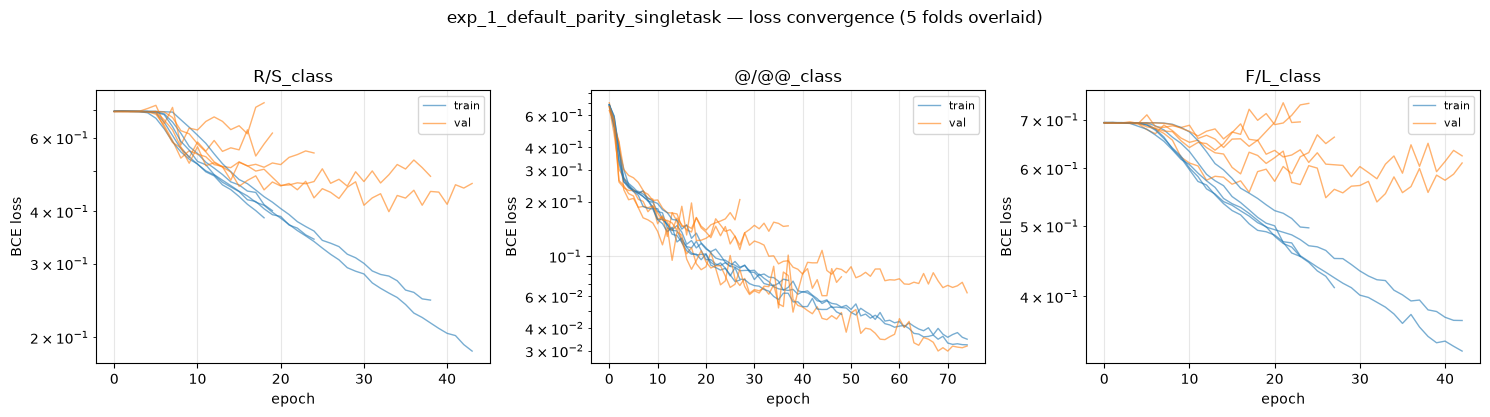

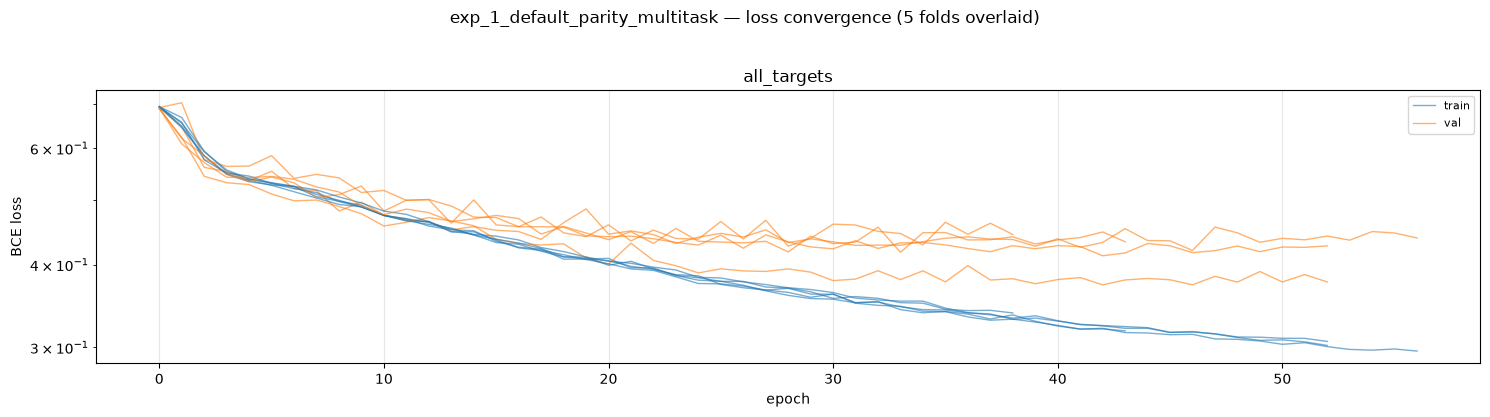

In [18]:
import matplotlib.pyplot as plt

def plot_loss_curves(curves_df, condition, figsize=(15, 4)):
    """Train vs. validation BCE per epoch, one panel per target, folds overlaid."""
    sub = curves_df[curves_df['featurization'] == condition]
    targets = sub['target'].unique()
    fig, axes = plt.subplots(1, len(targets), figsize=figsize, squeeze=False)

    for ax, target in zip(axes[0], targets):
        t = sub[sub['target'] == target]
        for fold, g in t.groupby('fold'):
            g = g.sort_values('epoch')
            ax.plot(g['epoch'], g['train_loss_epoch'], alpha=.6, lw=1,
                    color='tab:blue', label='train' if fold == 0 else None)
            ax.plot(g['epoch'], g['val_loss'], alpha=.6, lw=1,
                    color='tab:orange', label='val' if fold == 0 else None)
        ax.set_title(f'{target}')
        ax.set_xlabel('epoch')
        ax.set_ylabel('BCE loss')
        ax.set_yscale('log')
        ax.legend(fontsize=8)
        ax.grid(alpha=.3)

    n_folds = sub['fold'].nunique()
    fig.suptitle(f'{condition} — loss convergence ({n_folds} '
                 f"fold{'s' if n_folds != 1 else ''} overlaid)", y=1.03)
    fig.tight_layout()
    return fig


for cond in curves_df['featurization'].unique():
    plot_loss_curves(curves_df, cond)
    plt.show()

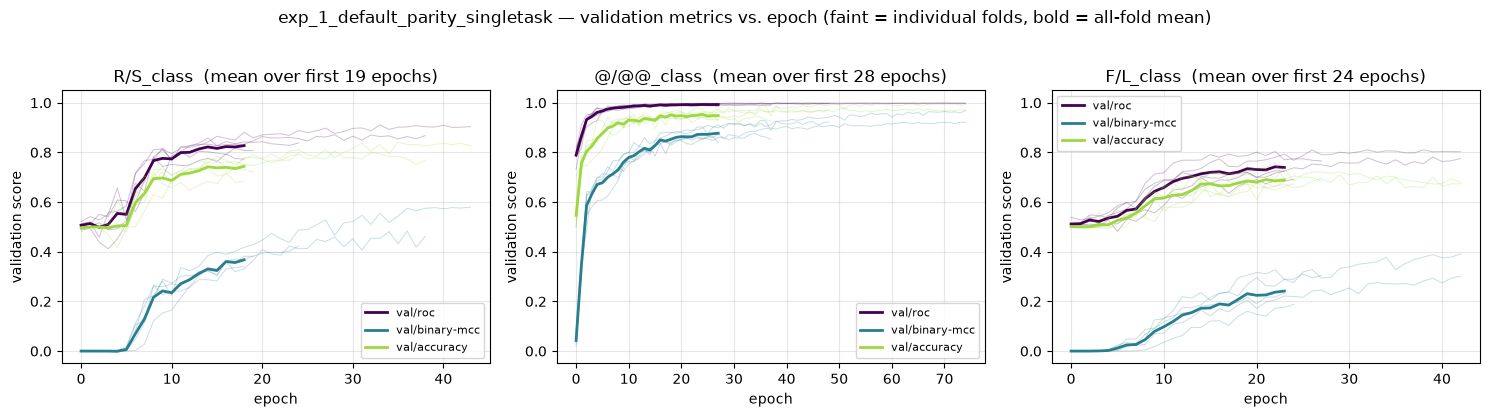

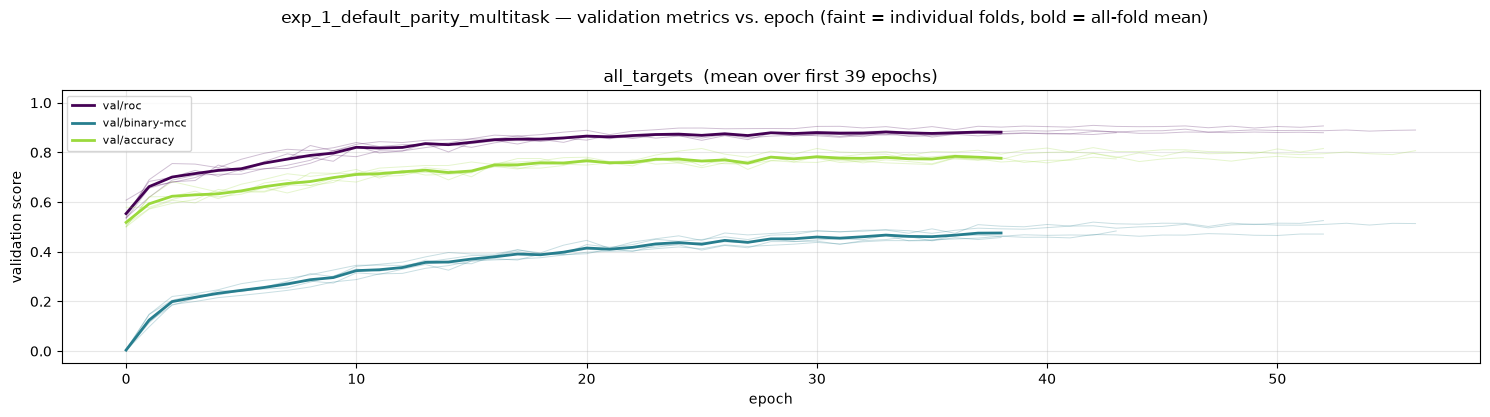

In [19]:
def _fold_mean(t, cols):
    """
    Fold-average `cols` per epoch, but only over epochs where EVERY fold is still training.

    Folds stop at different epochs, so a naive groupby('epoch').mean() silently averages
    over a shrinking subset: the tail of the curve would describe a different (and
    increasingly lucky) population than the head. Returns the complete-fold mean plus the
    fold count so callers can label what was dropped.
    """
    n_per_epoch = t.groupby('epoch')['fold'].nunique()
    n_folds = int(n_per_epoch.max())
    complete = n_per_epoch[n_per_epoch == n_folds].index
    return t[t['epoch'].isin(complete)].groupby('epoch')[cols].mean(), n_folds, len(n_per_epoch) - len(complete)


def plot_metric_curves(curves_df, condition, metrics=('val/roc', 'val/binary-mcc', 'val/accuracy'),
                       figsize=(15, 4)):
    """
    Validation metrics per epoch.

    Mind the mixed semantics of these three curves:
      * `val/roc` is threshold-free.
      * `val/accuracy` is thresholded at 0.5 by torchmetrics.
      * `val/binary-mcc` is NOT thresholded at all — chemprop's BinaryMCCMetric accumulates
        soft confusion counts straight from the probabilities, making it sensitive to
        confidence as well as ranking.
    None of them are comparable to the tuned-threshold metrics in the results CSV.

    Individual folds are drawn faintly; the bold line is the mean over epochs where all
    folds are still training (see `_fold_mean`).
    """
    sub = curves_df[curves_df['featurization'] == condition]
    targets = sub['target'].unique()
    fig, axes = plt.subplots(1, len(targets), figsize=figsize, squeeze=False)
    colors = plt.cm.viridis(np.linspace(0, .85, len(metrics)))

    for ax, target in zip(axes[0], targets):
        t = sub[sub['target'] == target]
        present = [m for m in metrics if m in t.columns]
        mean_df, n_folds, n_dropped = _fold_mean(t, present)
        for metric, color in zip(present, colors):
            for _, g in t.groupby('fold'):          # per-fold, faint
                g = g.sort_values('epoch')
                ax.plot(g['epoch'], g[metric], color=color, lw=.7, alpha=.25)
            ax.plot(mean_df.index, mean_df[metric], color=color, lw=2.0, label=metric)
        ax.set_title(f'{target}' + (f'  (mean over first {len(mean_df)} epochs)' if n_dropped else ''))
        ax.set_xlabel('epoch')
        ax.set_ylabel('validation score')
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=.3)

    fig.suptitle(f'{condition} — validation metrics vs. epoch '
                 f'(faint = individual folds, bold = all-fold mean)', y=1.03)
    fig.tight_layout()
    return fig


for cond in curves_df['featurization'].unique():
    plot_metric_curves(curves_df, cond)
    plt.show()

### The calibration diagnostic

`val_loss` against `val/roc` on twin axes. Where AUROC saturates while BCE keeps falling,
the model's *ranking* is already perfect and only its *probabilities* are still moving.
That region is why `ModelCheckpoint` must not monitor `val/roc`: a strict `>` comparison
means a saturated AUROC never replaces the saved checkpoint, freezing selection on an
early, uncalibrated epoch.

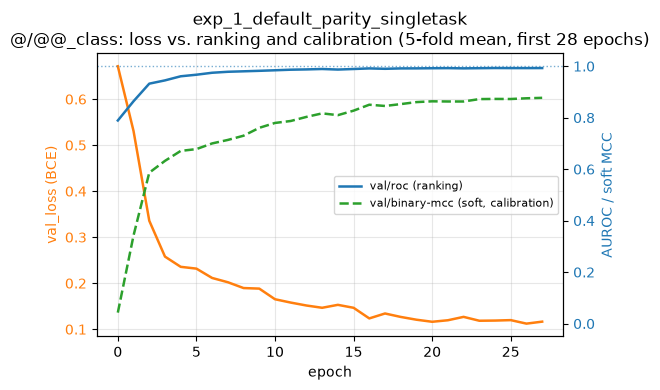

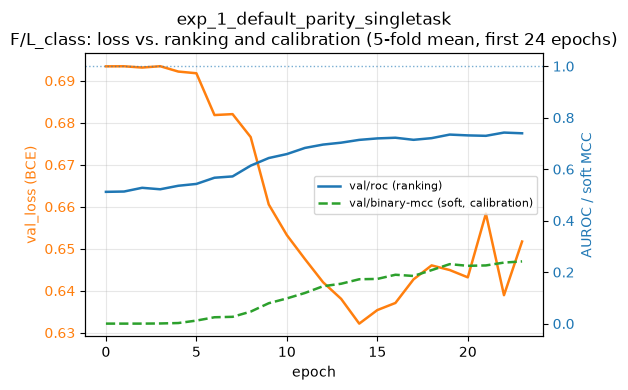

In [20]:
def plot_loss_vs_auroc(curves_df, condition, target, figsize=(6, 4)):
    """
    val_loss against ranking (val/roc) and calibration (soft val/binary-mcc) on twin axes.

    For a target whose AUROC saturates early (R/S), the gap shows that ranking is already
    perfect while the probabilities are still moving — which is why ModelCheckpoint must not
    monitor val/roc: a strict `>` comparison means a saturated AUROC never replaces the
    saved checkpoint. For a target whose AUROC never saturates (F/L), the three curves
    simply improve together.

    Restricted to epochs where all folds are still training (see `_fold_mean`).
    """
    t = curves_df[(curves_df['featurization'] == condition) & (curves_df['target'] == target)]
    cols = [c for c in ('val_loss', 'val/roc', 'val/binary-mcc') if c in t.columns]
    g, n_folds, n_dropped = _fold_mean(t, cols)

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.plot(g.index, g['val_loss'], color='tab:orange', lw=1.8, label='val_loss (BCE)')
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('val_loss (BCE)', color='tab:orange')
    ax1.tick_params(axis='y', labelcolor='tab:orange')

    ax2 = ax1.twinx()
    ax2.plot(g.index, g['val/roc'], color='tab:blue', lw=1.8, label='val/roc (ranking)')
    if 'val/binary-mcc' in g.columns:
        ax2.plot(g.index, g['val/binary-mcc'], color='tab:green', lw=1.8, ls='--',
                 label='val/binary-mcc (soft, calibration)')
    ax2.axhline(1.0, color='tab:blue', ls=':', lw=1, alpha=.6)
    ax2.set_ylabel('AUROC / soft MCC', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(loc='center right', fontsize=8)

    ax1.set_title(f'{condition}\n{target}: loss vs. ranking and calibration '
                  f'({n_folds}-fold mean, first {len(g)} epochs)')
    ax1.grid(alpha=.3)
    fig.tight_layout()
    return fig


for _t in ('@/@@_class', 'F/L_class'):
    plot_loss_vs_auroc(curves_df, 'exp_1_default_parity_singletask', _t)
    plt.show()